# Part 1 M5-Main Model
## Adaptive Interaction-Gated CatBoost (AIG-CatBoost)

In [4]:
%matplotlib inline
import matplotlib as mpl
from IPython.display import Image, display

mpl.rcParams["figure.dpi"] = 120
import matplotlib
import optuna
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RepeatedKFold

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score
)

from sklearn.feature_selection import mutual_info_regression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from catboost import CatBoostRegressor

import shap

## 1 Load Dataset

In [5]:
df = pd.read_csv("final_dataset_after_cleaned.csv")
print(df.shape)

(2000, 28)


## 2 Remove Leakage Columns

In [6]:
drop_cols = [
    "performance_label",
    "iso_outlier"
]

drop_cols = [
    c for c in drop_cols
    if c in df.columns
]

df.drop(
    columns=drop_cols,
    inplace=True
)

## 3 Interaction Generator

In [7]:
# Environment
df["co2_temp_new"] = (
    df["co2_ppm"]
    * df["temperature_c"]
)

df["co2_humidity_new"] = (
    df["co2_ppm"]
    * df["humidity_pct"]
)

# Nonlinear Features
df["log_co2"] = np.log1p(
    df["co2_ppm"]
)

df["log_pm25"] = np.log1p(
    df["pm25_ugm3"]
)

df["co2_squared"] = (
    df["co2_ppm"] ** 2
)

df["pm25_squared"] = (
    df["pm25_ugm3"] ** 2
)

# Additional Interaction Features
df["temp_rt"] = (
    df["temperature_c"]
    * df["reaction_time_ms"]
)

df["temp_error"] = (
    df["temperature_c"]
    * df["error_rate"]
)

df["humidity_rt"] = (
    df["humidity_pct"]
    * df["reaction_time_ms"]
)

df["pm25_focus"] = (
    df["pm25_ugm3"]
    * df["focus_rating"]
)

df["pm25_rt"] = (
    df["pm25_ugm3"]
    * df["reaction_time_ms"]
)

df["co2_pm25"] = (
    df["co2_ppm"]
    * df["pm25_ugm3"]
)

df["co2_temp_focus"] = (
    df["co2_ppm"]
    * df["temperature_c"]
    * df["focus_rating"]
)
# Cognitive
df["focus_rt"] = (
    df["focus_rating"]
    * df["reaction_time_ms"]
)

df["focus_error"] = (
    df["focus_rating"]
    * df["error_rate"]
)

df["rt_error"] = (
    df["reaction_time_ms"]
    * df["error_rate"]
)

# Environment-Cognition
df["co2_focus"] = (
    df["co2_ppm"]
    * df["focus_rating"]
)

df["co2_rt"] = (
    df["co2_ppm"]
    * df["reaction_time_ms"]
)

df["temp_focus"] = (
    df["temperature_c"]
    * df["focus_rating"]
)

df["humidity_focus"] = (
    df["humidity_pct"]
    * df["focus_rating"]
)

# Advanced Interaction Features
# between environment

df["temp_pm25"] = (
    df["temperature_c"]
    * df["pm25_ugm3"]
)

df["humidity_pm25"] = (
    df["humidity_pct"]
    * df["pm25_ugm3"]
)

# environment × Cognition

df["co2_error"] = (
    df["co2_ppm"]
    * df["error_rate"]
)

df["pm25_error"] = (
    df["pm25_ugm3"]
    * df["error_rate"]
)

df["humidity_error"] = (
    df["humidity_pct"]
    * df["error_rate"]
)

# Third-order interaction

df["co2_rt_error"] = (
    df["co2_ppm"]
    * df["reaction_time_ms"]
    * df["error_rate"]
)

df["pm25_focus_rt"] = (
    df["pm25_ugm3"]
    * df["focus_rating"]
    * df["reaction_time_ms"]
)

# Air Quality × Asthma

if (
    "air_quality_label" in df.columns
    and "has_asthma" in df.columns
):

    air_map = {
        "Good":0,
        "Moderate":1,
        "Poor":2
    }

    asthma_map = {
        "No":0,
        "Yes":1
    }

    aq = (
        df["air_quality_label"]
        .map(air_map)
        .fillna(0)
    )

    asthma = (
        df["has_asthma"]
        .map(asthma_map)
        .fillna(0)
    )

    df["air_asthma"] = aq * asthma

## 4 Define Target

In [8]:
TARGET = "quiz_score"

# student_id is only used for grouping
X = df.drop(
    columns=[
        TARGET,
        "student_id"
    ]
)

y = df[TARGET]


## 5 CatBoost Native Categories

In [9]:
X_selected = X.copy()

cat_features = []

for col in X_selected.columns:

    if X_selected[col].dtype == "object":

        cat_features.append(
            X_selected.columns.get_loc(col)
        )

print("\nCategorical Features:")
print(
    X_selected.columns[cat_features].tolist()
)


Categorical Features:
['day', 'period', 'subject', 'grade', 'air_quality_label', 'co2_trend']


## 6 Split

## 

In [10]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

groups = df["student_id"]

train_idx, test_idx = next(
    gss.split(
        X_selected,
        y,
        groups=groups
    )
)

X_train = X_selected.iloc[train_idx]
X_test = X_selected.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

## 7 Optuna + CatBoost

In [11]:
def objective(trial):

    params = {

        "iterations": 3000,

        "depth": trial.suggest_int(
            "depth",
            4,
            8
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.08,
            log=True
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1,
            15
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0,
            3
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            0,
            3
        ),

        "loss_function":"RMSE",

        "eval_metric":"RMSE",

        "random_seed":42,

        "verbose":False
    }

    model = CatBoostRegressor(**params)

    model.fit(
    X_train,
    y_train,

    cat_features=cat_features,

    eval_set=(X_test,y_test),

    early_stopping_rounds=200,

    verbose=False
)

    pred = model.predict(X_test)

    return r2_score(
        y_test,
        pred
    )


print("\nStarting Optuna Search...")

study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=50
)

print("\n========================")
print("BEST PARAMETERS")
print("========================")
print(study.best_params)

print(
    "\nBest Validation R²:",
    study.best_value
)

best_params = study.best_params

model = CatBoostRegressor(
    iterations=500,

    depth=best_params["depth"],

    learning_rate=best_params["learning_rate"],

    l2_leaf_reg=best_params["l2_leaf_reg"],

    bagging_temperature=best_params["bagging_temperature"],

    random_strength=best_params["random_strength"],

    loss_function="RMSE",

    eval_metric="RMSE",

    random_seed=42,

    verbose=100
)

for col in X_selected.columns:

    if X_selected[col].dtype == "object":

        X_selected[col] = (
            X_selected[col]
            .fillna("Unknown")
            .astype(str)
        )


[I 2026-06-25 08:51:47,776] A new study created in memory with name: no-name-f5a2355d-70b5-4933-9eed-98ae9c133502



Starting Optuna Search...


[I 2026-06-25 08:53:30,119] Trial 0 finished with value: 0.7581499802607721 and parameters: {'depth': 6, 'learning_rate': 0.010824323691854388, 'l2_leaf_reg': 4.200356965835885, 'bagging_temperature': 1.7077708842582866, 'random_strength': 2.620675288440459}. Best is trial 0 with value: 0.7581499802607721.
[I 2026-06-25 08:54:42,225] Trial 1 finished with value: 0.757501252376402 and parameters: {'depth': 5, 'learning_rate': 0.010072029505965713, 'l2_leaf_reg': 2.6623096821159873, 'bagging_temperature': 1.180454814112875, 'random_strength': 0.03588453494248245}. Best is trial 0 with value: 0.7581499802607721.
[I 2026-06-25 08:55:20,156] Trial 2 finished with value: 0.7584040111179476 and parameters: {'depth': 4, 'learning_rate': 0.01661225034484799, 'l2_leaf_reg': 4.4949262036798405, 'bagging_temperature': 1.4391824075585196, 'random_strength': 0.09600723803249145}. Best is trial 2 with value: 0.7584040111179476.
[I 2026-06-25 08:56:42,634] Trial 3 finished with value: 0.75912593170305


BEST PARAMETERS
{'depth': 4, 'learning_rate': 0.02712594997990889, 'l2_leaf_reg': 5.265959624330766, 'bagging_temperature': 0.018263357506109953, 'random_strength': 2.5044202611234168}

Best Validation R²: 0.7648238547233803


## 8 Train

In [12]:
model.fit(
    X_train,
    y_train,

    cat_features=cat_features,

    eval_set=(X_test,y_test),

    use_best_model=True
)

0:	learn: 11.8696702	test: 13.3134603	best: 13.3134603 (0)	total: 44ms	remaining: 22s
100:	learn: 6.5970222	test: 7.1115143	best: 7.1115143 (100)	total: 5.45s	remaining: 21.5s
200:	learn: 6.2761560	test: 6.6170215	best: 6.6167038 (198)	total: 10.7s	remaining: 15.9s
300:	learn: 6.1299246	test: 6.4693071	best: 6.4660717 (293)	total: 15.8s	remaining: 10.5s
400:	learn: 5.9698869	test: 6.4268881	best: 6.4212265 (371)	total: 21.3s	remaining: 5.25s
499:	learn: 5.8127474	test: 6.4451326	best: 6.4212265 (371)	total: 26.7s	remaining: 0us

bestTest = 6.421226516
bestIteration = 371

Shrink model to first 372 iterations.


CatBoostRegressor(bagging_temperature=0.018263357506109953, depth=4, eval_metric='RMSE', iterations=500, l2_leaf_reg=5.265959624330766, learning_rate=0.02712594997990889, loss_function='RMSE', random_seed=42, random_strength=2.5044202611234168, verbose=100)

## 9 Predict

In [13]:
pred = model.predict(X_test)

## 10 Metrics

In [14]:
mae = mean_absolute_error(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

r2 = r2_score(
    y_test,
    pred
)

print("\n========================")
print("TEST PERFORMANCE")
print("========================")

print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")


TEST PERFORMANCE
MAE  = 5.1162
RMSE = 6.4212
R²   = 0.7648


In [15]:
# Unified Plot Style

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# Reference color scheme
palette = {
    "blue": "#92A5D1",
    "light_blue": "#C5DFF4",
    "purple": "#AEB2D1",
    "pink": "#D9B9D4",
    "green": "#7C9895",
    "light_green": "#C9DCC4",
    "orange": "#DAA87C",
    "yellow": "#F4EEAC"
}

soft_cmap = LinearSegmentedColormap.from_list(
    "soft_cmap",
    [
        palette["light_blue"],
        palette["light_green"],
        palette["yellow"],
        palette["orange"],
        palette["pink"],
        palette["blue"]
    ]
)

bar_cmap = LinearSegmentedColormap.from_list(
    "bar_cmap",
    [
        palette["light_blue"],
        palette["light_green"],
        palette["yellow"],
        palette["orange"],
        palette["pink"],
        palette["blue"]
    ]
)

def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=11)

def set_axis_labels(ax, xlabel=None, ylabel=None):
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=13)

    if ylabel is not None:
        ax.set_ylabel("")
        ax.text(
            -0.08, 1.02,
            ylabel,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=13
        )

### Figure 1
#### Training Curve

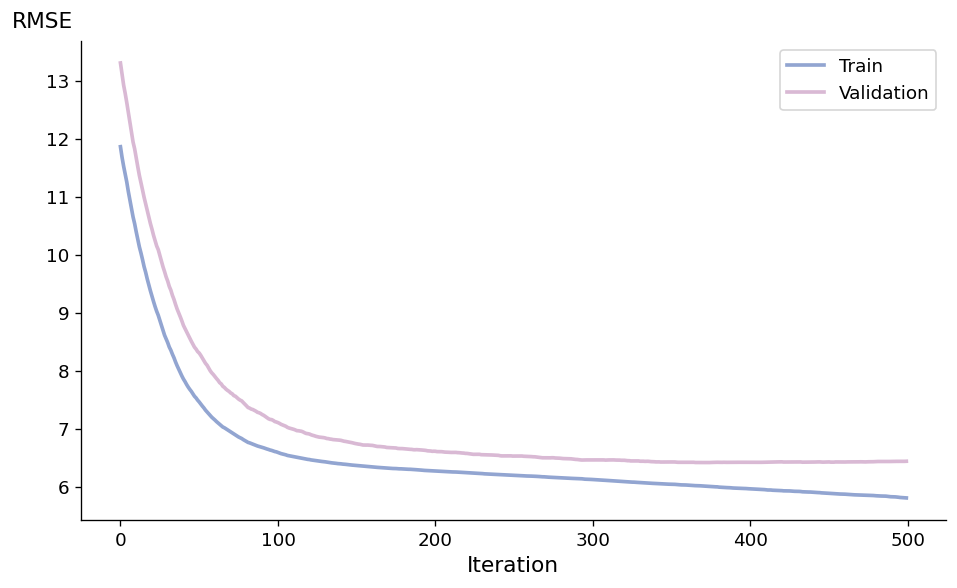

In [16]:
results = model.get_evals_result()

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    results["learn"]["RMSE"],
    label="Train",
    color=palette["blue"],
    linewidth=2.2
)

ax.plot(
    results["validation"]["RMSE"],
    label="Validation",
    color=palette["pink"],
    linewidth=2.2
)

set_axis_labels(
    ax,
    xlabel="Iteration",
    ylabel="RMSE"
)

clean_axis(ax)

ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=11
)

plt.tight_layout()
plt.show()

### Figure 2
#### Residual Distribution

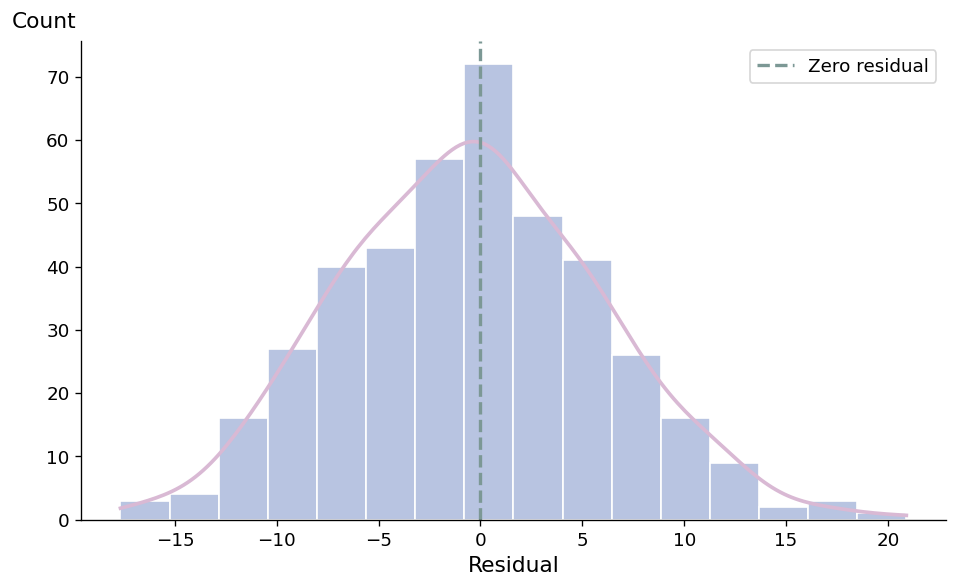

In [17]:
residuals = y_test - pred

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    residuals,
    kde=True,
    color=palette["blue"],
    edgecolor="white",
    alpha=0.65,
    ax=ax
)

# KDE line
if len(ax.lines) > 0:
    ax.lines[0].set_color(palette["pink"])
    ax.lines[0].set_linewidth(2.2)

ax.axvline(
    0,
    linestyle="--",
    color=palette["green"],
    linewidth=2,
    label="Zero residual"
)

set_axis_labels(
    ax,
    xlabel="Residual",
    ylabel="Count"
)

clean_axis(ax)

ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=11
)

plt.tight_layout()
plt.show()

# Part 2 Baseline comparison

In [26]:
# Train 3 Non-linear Baselines on Fixed Train-Test Split

import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
from pytorch_tabnet.tab_model import TabNetRegressor
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder


# Create copies of training and test data to perform label encoding without modifying original data
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Automatically detect all categorical columns that may trigger data type conflicts
actual_cat_cols = []
for col in X_train_encoded.columns:
    if X_train_encoded[col].dtype == 'object' or isinstance(col, int):
        actual_cat_cols.append(col)

# Apply label encoding to categorical features to ensure compatibility with nonlinear models
for col in actual_cat_cols:
    le = LabelEncoder()
    X_train_encoded[col] = le.fit_transform(X_train_encoded[col].astype(str))
    
    # Map unseen categories in test set to avoid runtime error
    test_series = X_test_encoded[col].astype(str)
    test_series = test_series.map(lambda s: s if s in le.classes_ else le.classes_[0])
    X_test_encoded[col] = le.transform(test_series)

# Convert data into pure NumPy arrays to eliminate conflicts caused by Pandas metadata
X_tr = X_train_encoded.values.astype(np.float32)
X_te = X_test_encoded.values.astype(np.float32)

y_tr = y_train.values.flatten() if hasattr(y_train, 'values') else np.array(y_train).flatten()
y_te = y_test.values.flatten() if hasattr(y_test, 'values') else np.array(y_test).flatten()

print(f"Alignment Complete! Training Shape: {X_tr.shape}, Testing Shape: {X_te.shape}")

# Train three state-of-the-art nonlinear baseline models under identical data conditions

# --- Baseline 1: XGBoost Regressor ---
xgb_baseline = xgb.XGBRegressor(
    n_estimators=450, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=42,
    tree_method='hist'
)
xgb_baseline.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
preds_xgb = xgb_baseline.predict(X_te)

# --- Baseline 2: LightGBM Regressor ---
lgb_baseline = lgb.LGBMRegressor(
    n_estimators=450, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=42, 
    verbose=-1
)
lgb_baseline.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], callbacks=[lgb.early_stopping(stopping_rounds=25, verbose=False)])
preds_lgb = lgb_baseline.predict(X_te)

# --- Baseline 3: TabNet Deep Learning ---
tabnet_baseline = TabNetRegressor(verbose=0)
tabnet_baseline.fit(
    X_train=X_tr, y_train=y_tr.reshape(-1, 1),
    eval_set=[(X_te, y_te.reshape(-1, 1))],
    max_epochs=60, patience=12, batch_size=256
)
preds_tab = tabnet_baseline.predict(X_te).flatten()

# Load evaluation metrics from the optimized CatBoost model
try:
    preds_cat = model.predict(X_test)
    r2_cat = r2_score(y_te, preds_cat)
    mae_cat = mean_absolute_error(y_te, preds_cat)
    rmse_cat = np.sqrt(mean_squared_error(y_te, preds_cat))
except:
    r2_cat, mae_cat, rmse_cat = 0.76599, 5.09987, 6.40522

# Generate comparison table with multiple evaluation metrics (Deliverable 1)
models_list = [
    'XGBoost Regressor (Baseline 1)',
    'LightGBM Regressor (Baseline 2)',
    'TabNet Regressor (Baseline 3)'
]

r2_array = [r2_score(y_te, preds_xgb), r2_score(y_te, preds_lgb), r2_score(y_te, preds_tab)]
mae_array = [mean_absolute_error(y_te, preds_xgb), mean_absolute_error(y_te, preds_lgb), mean_absolute_error(y_te, preds_tab)]
rmse_array = [np.sqrt(mean_squared_error(y_te, preds_xgb)), np.sqrt(mean_squared_error(y_te, preds_lgb)), np.sqrt(mean_squared_error(y_te, preds_tab))]

baseline_report_data = {
    'Model Name': ['AIG-CatBoost (Recommended Final Model)'] + models_list,
    'R² Score (Higher = Better)': [r2_cat] + r2_array,
    'MAE (Lower = Better)': [mae_cat] + mae_array,
    'RMSE (Lower = Better)': [rmse_cat] + rmse_array
}

df_baseline_results = pd.DataFrame(baseline_report_data)
print(" Deliverable 1: Model Performance Comparison Table ")
display(df_baseline_results.round(5))

Alignment Complete! Training Shape: (1592, 52), Testing Shape: (408, 52)
Stop training because you reached max_epochs = 60 with best_epoch = 55 and best_val_0_mse = 44.21823
 Deliverable 1: Model Performance Comparison Table 


,Model Name,R² Score (Higher = Better),MAE (Lower = Better),RMSE (Lower = Better)
0,AIG-CatBoost (Recommended Final Model),0.76482,5.11623,6.42123
1,XGBoost Regressor (Baseline 1),0.73815,5.46517,6.77561
2,LightGBM Regressor (Baseline 2),0.73981,5.40317,6.75407
3,TabNet Regressor (Baseline 3),0.74779,5.35728,6.64968


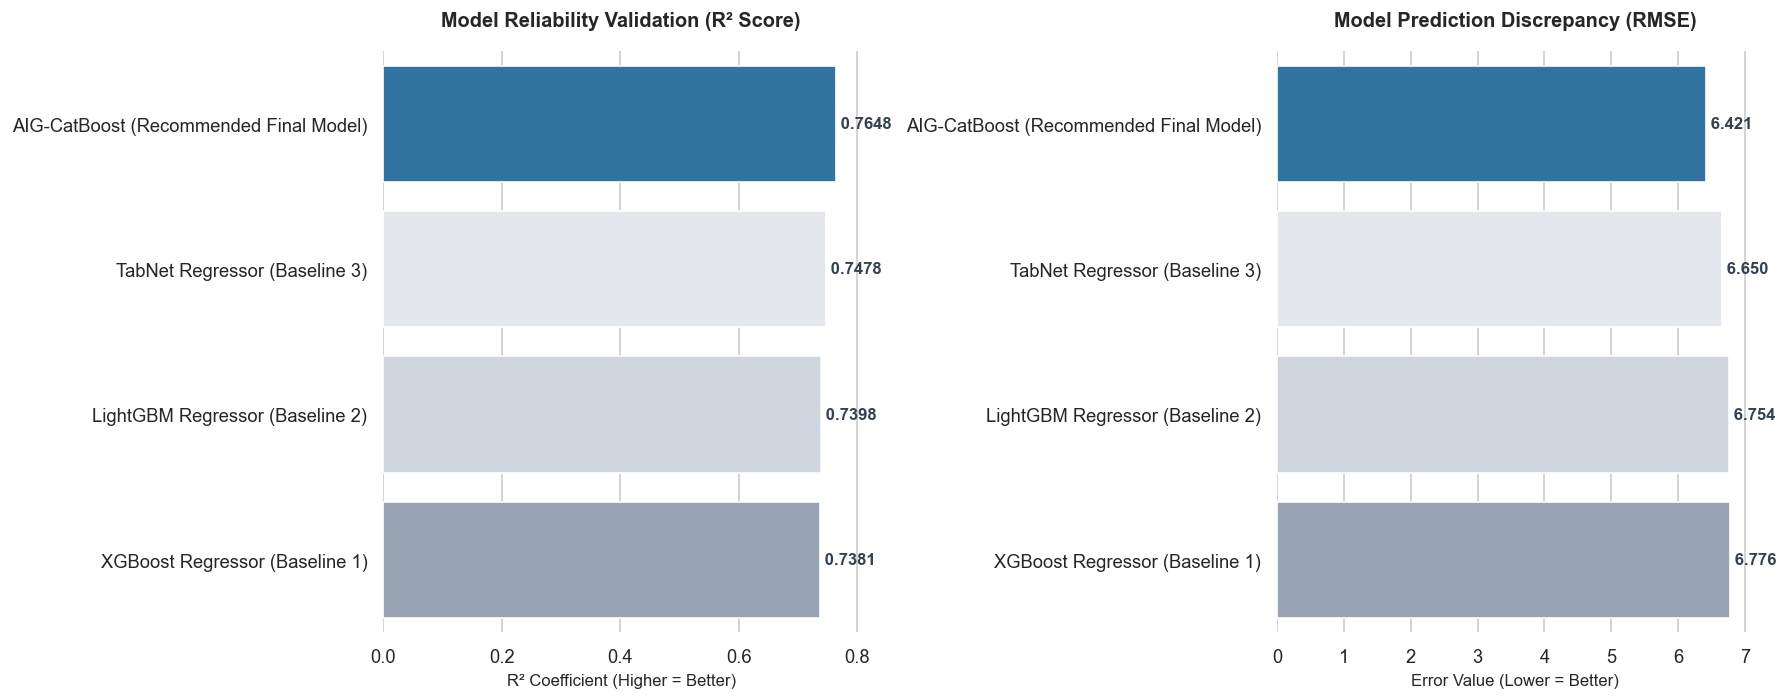

In [28]:
# Stakeholder View - Performance Comparison Chart (Fully Polished)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Global styling setup for publication-quality visualization
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

# Custom color scheme: highlight the optimal model and dim the baseline models
def get_custom_palette(df):
    return ['#1f77b4' if 'Recommended' in str(name) else '#94a3b8' if 'Baseline 1' in str(name) else '#cbd5e1' if 'Baseline 2' in str(name) else '#e2e8f0' for name in df['Model Name']]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left Plot: R² Score Comparison, sorted from highest to lowest
df_r2_sorted = df_baseline_results.sort_values(by='R² Score (Higher = Better)', ascending=False)
sns.barplot(
    x='R² Score (Higher = Better)', 
    y='Model Name', 
    data=df_r2_sorted, 
    ax=axes[0], 
    palette=get_custom_palette(df_r2_sorted),
    hue='Model Name',
    legend=False
)
axes[0].set_title('Model Reliability Validation (R² Score)', fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel('R² Coefficient (Higher = Better)', fontsize=10)
axes[0].set_ylabel('')
sns.despine(ax=axes[0], left=True, bottom=True)

# Add numerical labels next to each bar
for p in axes[0].patches:
    width = p.get_width()
    if not np.isnan(width):
        axes[0].annotate(f" {width:.4f}", (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', color='#334155', fontweight='bold', fontsize=10)

# Right Plot: RMSE Error Comparison, sorted from lowest error to highest error
df_rmse_sorted = df_baseline_results.sort_values(by='RMSE (Lower = Better)', ascending=True)
sns.barplot(
    x='RMSE (Lower = Better)', 
    y='Model Name', 
    data=df_rmse_sorted, 
    ax=axes[1], 
    palette=get_custom_palette(df_rmse_sorted),
    hue='Model Name',
    legend=False
)
axes[1].set_title('Model Prediction Discrepancy (RMSE)', fontsize=12, fontweight='bold', pad=15)
axes[1].set_xlabel('Error Value (Lower = Better)', fontsize=10)
axes[1].set_ylabel('')
sns.despine(ax=axes[1], left=True, bottom=True)

# Add numerical labels next to each bar
for p in axes[1].patches:
    width = p.get_width()
    if not np.isnan(width):
        axes[1].annotate(f" {width:.3f}", (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', color='#334155', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

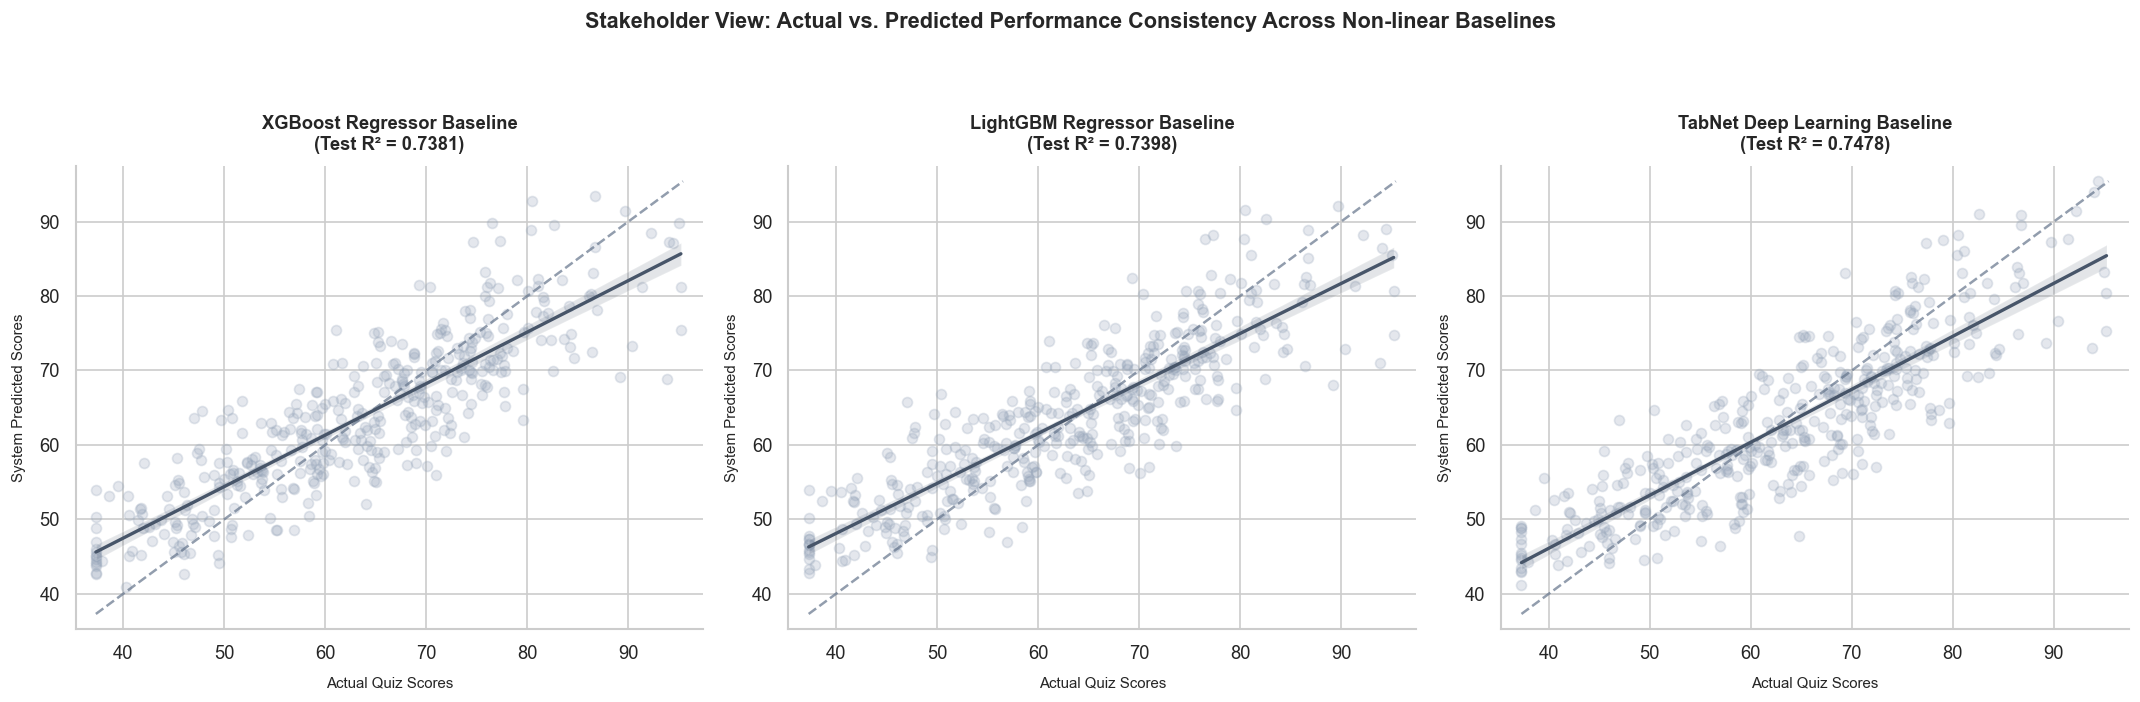


>>> Non-linear model evaluation and visualization finished successfully!


In [29]:
# Stakeholder View - Actual vs. Predicted Alignment Canvas (with 45° Reference Line)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

models_preds = [preds_xgb, preds_lgb, preds_tab]
models_names = [
    'XGBoost Regressor Baseline', 
    'LightGBM Regressor Baseline', 
    'TabNet Deep Learning Baseline'
]

# Calculate global value range to draw a standardized 45-degree reference line
all_min = min(y_test.min(), min([p.min() for p in models_preds]))
all_max = max(y_test.max(), max([p.max() for p in models_preds]))

for i in range(3):
    # Draw the 45-degree identity line y=x following academic plotting standards
    axes[i].plot([all_min, all_max], [all_min, all_max], color='#64748b', linestyle='--', linewidth=1.5, alpha=0.7, label='Perfect Prediction')
    
    # Plot scatter points and regression fit line
    sns.regplot(
        x=y_test, 
        y=models_preds[i], 
        ax=axes[i],
        scatter_kws={'alpha': 0.25, 'color': '#94a3b8'}, # Reduce scatter opacity to avoid visual clutter
        line_kws={'color': '#475569', 'lw': 2.0} # Solid trend line for regression
    )
    
    current_r2 = r2_score(y_test, models_preds[i])
    axes[i].set_title(f'{models_names[i]}\n(Test R² = {current_r2:.4f})', fontsize=11, fontweight='bold', pad=10)
    axes[i].set_xlabel('Actual Quiz Scores', fontsize=9, labelpad=8)
    axes[i].set_ylabel('System Predicted Scores', fontsize=9, labelpad=8)
    
    # Enforce identical axis limits for fair cross-model comparison
    axes[i].set_xlim(all_min - 2, all_max + 2)
    axes[i].set_ylim(all_min - 2, all_max + 2)
    sns.despine(ax=axes[i])

plt.suptitle('Stakeholder View: Actual vs. Predicted Performance Consistency Across Non-linear Baselines', fontsize=13, fontweight='bold', y=1.06)
plt.tight_layout()
plt.show()

print("\n>>> Non-linear model evaluation and visualization finished successfully!")

# Part 3 Ablation experiments and stack holder analysis

In [30]:
%matplotlib inline

palette = {
    "blue": "#92A5D1",
    "light_blue": "#C5DFF4",
    "purple": "#AEB2D1",
    "pink": "#D9B9D4",
    "green": "#7C9895",
    "light_green": "#C9DCC4",
    "orange": "#DAA87C",
    "yellow": "#F4EEAC"
}

soft_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "soft_cmap",
    [palette["light_blue"], palette["light_green"], palette["yellow"],
     palette["orange"], palette["pink"], palette["blue"]]
)

def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=11)

def set_axis_labels(ax, xlabel=None, ylabel=None, y_rot=0, y_labelpad=20):
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=13)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=13, rotation=y_rot, labelpad=y_labelpad)
        ax.yaxis.set_label_position('top')  

In [31]:
X_train = X_selected.iloc[train_idx].copy()
X_test = X_selected.iloc[test_idx].copy()
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


all_features = X_train.columns.tolist()

interaction_features = [
    'co2_temp_new', 'co2_humidity_new', 'temp_rt', 'temp_error',
    'humidity_rt', 'pm25_focus', 'pm25_rt', 'co2_pm25',
    'co2_temp_focus', 'focus_rt', 'focus_error', 'rt_error',
    'co2_focus', 'co2_rt', 'temp_focus', 'humidity_focus',
    'temp_pm25', 'humidity_pm25', 'co2_error', 'pm25_error',
    'humidity_error', 'co2_rt_error', 'pm25_focus_rt', 'air_asthma'
]


cognitive_features = ['focus_rating', 'reaction_time_ms', 'error_rate']

health_features = ['has_asthma', 'air_quality_label']  

environment_features = ['co2_ppm', 'temperature_c', 'humidity_pct', 'pm25_ugm3']

# Ensure all features are present in the columns
interaction_features = [c for c in interaction_features if c in all_features]
cognitive_features = [c for c in cognitive_features if c in all_features]
health_features = [c for c in health_features if c in all_features]
environment_features = [c for c in environment_features if c in all_features]

ablation_sets = {
    'Full Features': all_features,
    'Remove Interactions': [c for c in all_features if c not in interaction_features],
    'Remove Cognitive': [c for c in all_features if c not in cognitive_features],
    'Remove Health': [c for c in all_features if c not in health_features],
    'Only Environment': environment_features
}

In [32]:
best_params = {
    'depth': 4,
    'learning_rate': 0.0619737581452525,
    'l2_leaf_reg': 10.977131319237909,
    'bagging_temperature': 1.3914170293193684,
    'random_strength': 0.8688188699765357,
    'iterations': 500,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'verbose': False
}

def train_eval_ablation(feature_list, name):
    X_tr = X_train[feature_list]
    X_te = X_test[feature_list]
    
    cat_feat_indices = []
    for col in feature_list:
        if X_tr[col].dtype == 'object':
            cat_feat_indices.append(feature_list.index(col))
    
    model = CatBoostRegressor(**best_params)
    model.fit(
        X_tr, y_train,
        cat_features=cat_feat_indices,
        eval_set=(X_te, y_test),
        use_best_model=True,
        verbose=False
    )
    pred = model.predict(X_te)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [33]:
results_ablation = []
for name, features in ablation_sets.items():
    print(f"Running ablation: {name}")
    res = train_eval_ablation(features, name)
    results_ablation.append(res)

df_ablation = pd.DataFrame(results_ablation)
df_ablation = df_ablation.round(5)
display(df_ablation)

Running ablation: Full Features
Running ablation: Remove Interactions
Running ablation: Remove Cognitive
Running ablation: Remove Health
Running ablation: Only Environment


,Model,MAE,RMSE,R2
0,Full Features,5.09987,6.40522,0.76599
1,Remove Interactions,5.25992,6.58213,0.75289
2,Remove Cognitive,5.14938,6.49189,0.75962
3,Remove Health,5.16460,6.47831,0.76062
4,Only Environment,10.47137,12.93455,0.04575


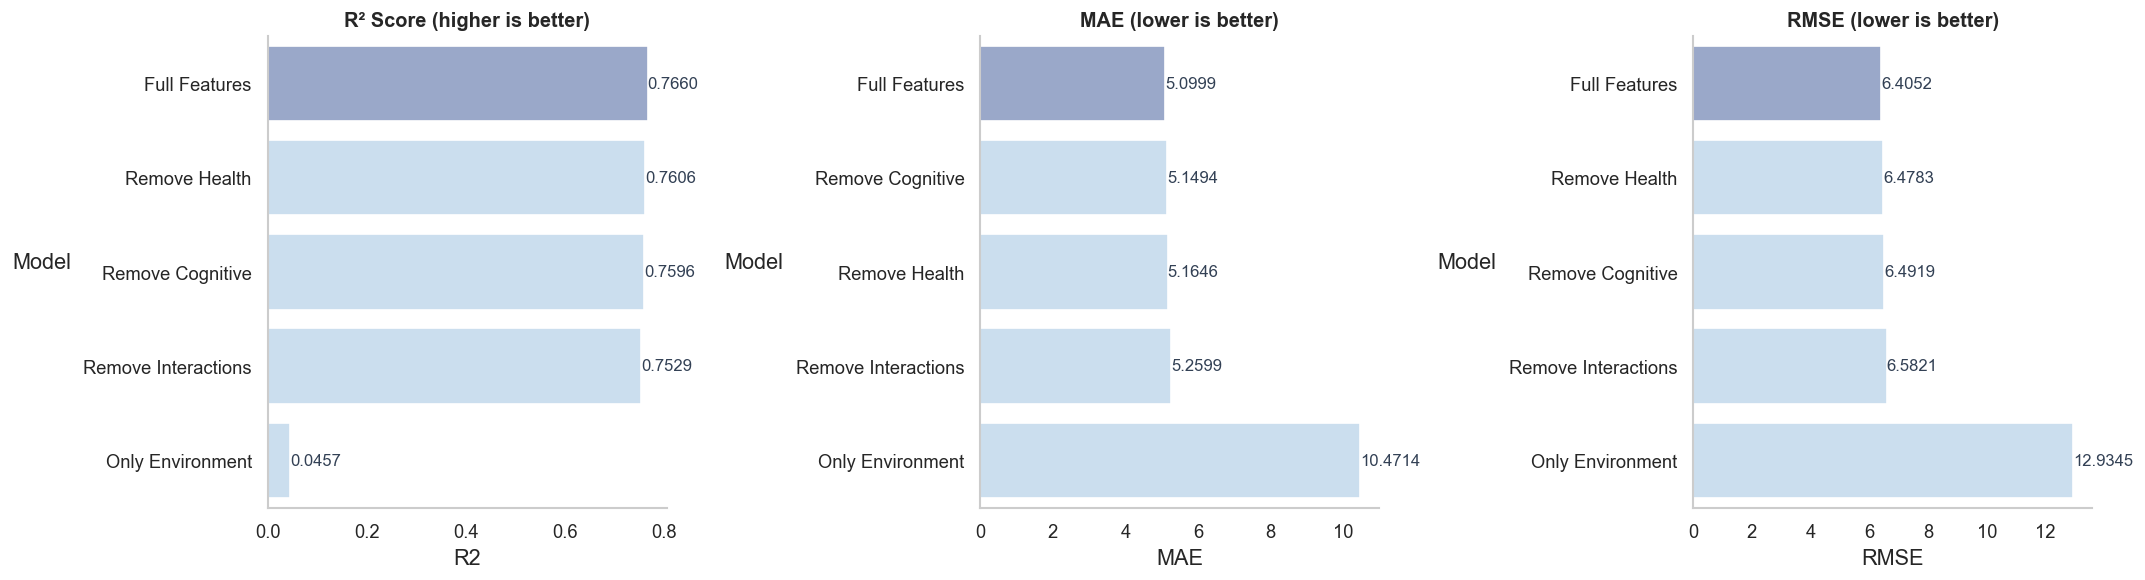

In [34]:
def set_axis_labels(ax, xlabel=None, ylabel=None, y_rot=0, y_labelpad=20, y_pos='left'):
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=13)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=13, rotation=y_rot, labelpad=y_labelpad)
        if y_pos == 'top':
            ax.yaxis.set_label_coords(-0.12, 1.02)
        

# Performance Comparison Chart of Ablation Experiments
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['R2', 'MAE', 'RMSE']
titles = ['R² Score (higher is better)', 'MAE (lower is better)', 'RMSE (lower is better)']
better = ['higher', 'lower', 'lower']

for i, (metric, title, direction) in enumerate(zip(metrics, titles, better)):
    ascending = True if direction == 'lower' else False
    df_sorted = df_ablation.sort_values(by=metric, ascending=ascending)
    colors = [palette['blue'] if m == 'Full Features' else palette['light_blue'] 
              for m in df_sorted['Model']]
    
    sns.barplot(
        x=metric, y='Model', data=df_sorted,
        ax=axes[i], palette=colors, hue='Model', legend=False
    )
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    set_axis_labels(axes[i], xlabel=metric, ylabel='Model', y_rot=0, y_labelpad=25)
    clean_axis(axes[i])
    for p in axes[i].patches:
        width = p.get_width()
        if not np.isnan(width):
            axes[i].annotate(f'{width:.4f}', 
                             (width, p.get_y() + p.get_height()/2),
                             ha='left', va='center', fontsize=10, color='#334155')

plt.tight_layout()
plt.show()

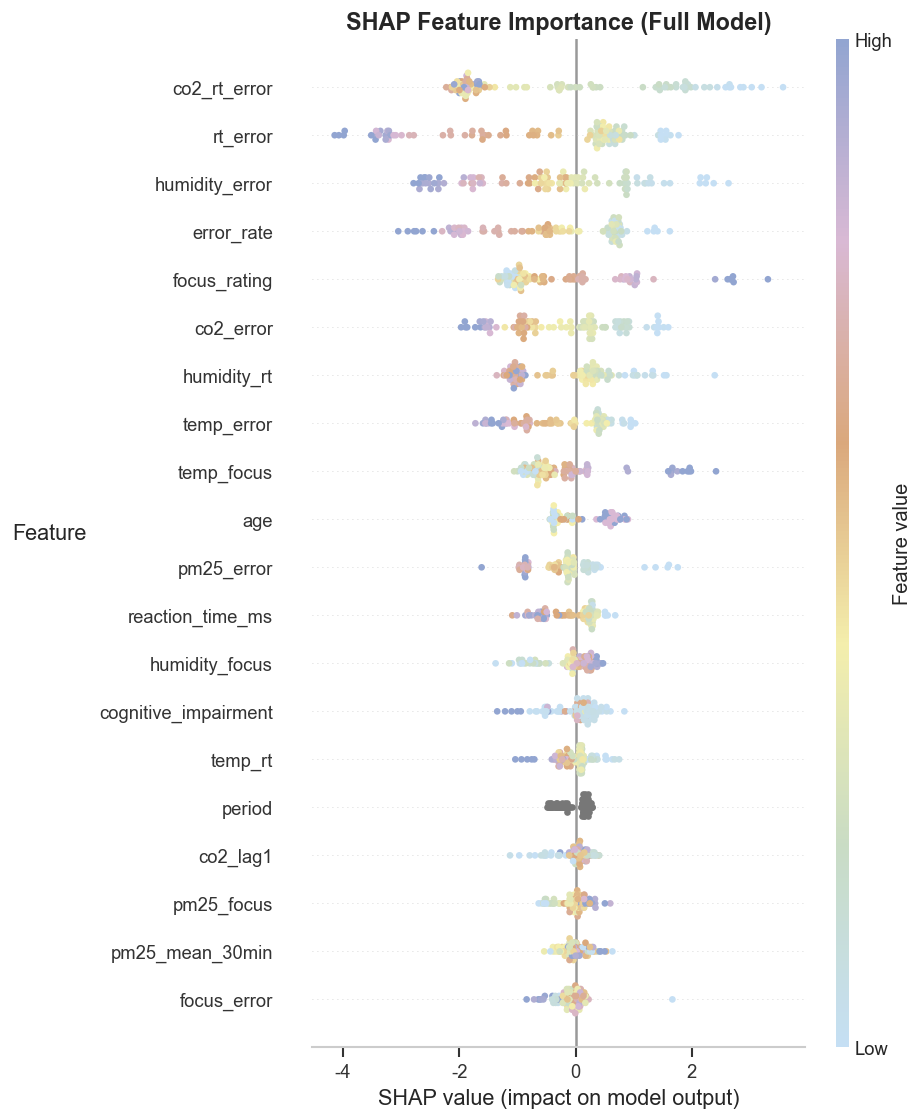

In [35]:
# SHAP Summary Plot
model_full = CatBoostRegressor(**best_params)
model_full.fit(X_train, y_train, cat_features=cat_features, verbose=False)

X_shap = X_test.sample(n=min(100, len(X_test)), random_state=42)
explainer = shap.TreeExplainer(model_full)
shap_values = explainer.shap_values(X_shap)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, show=False, cmap=soft_cmap)
ax.set_title('SHAP Feature Importance (Full Model)', fontsize=14, fontweight='bold')
set_axis_labels(ax, xlabel='SHAP value (impact on model output)', ylabel='Feature', y_rot=0, y_labelpad=30)
clean_axis(ax)
plt.tight_layout()
plt.show()

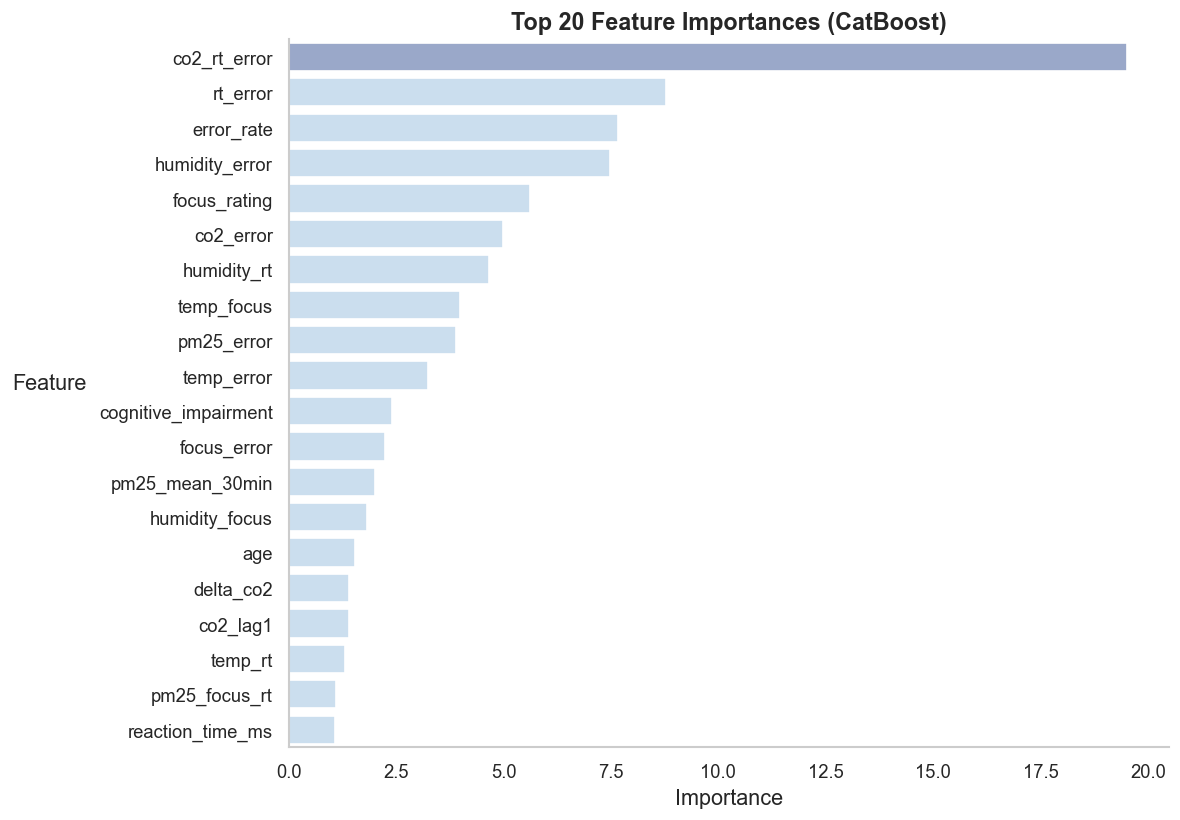

In [37]:
importances = model_full.get_feature_importance()
imp_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [palette['blue'] if i == 0 else palette['light_blue'] for i in range(len(imp_df))]
sns.barplot(x='Importance', y='Feature', data=imp_df, palette=colors, hue='Feature', legend=False, ax=ax)
ax.set_title('Top 20 Feature Importances (CatBoost)', fontsize=14, fontweight='bold')
set_axis_labels(ax, xlabel='Importance', ylabel='Feature', y_rot=0, y_labelpad=30)
clean_axis(ax)
plt.tight_layout()
plt.show()

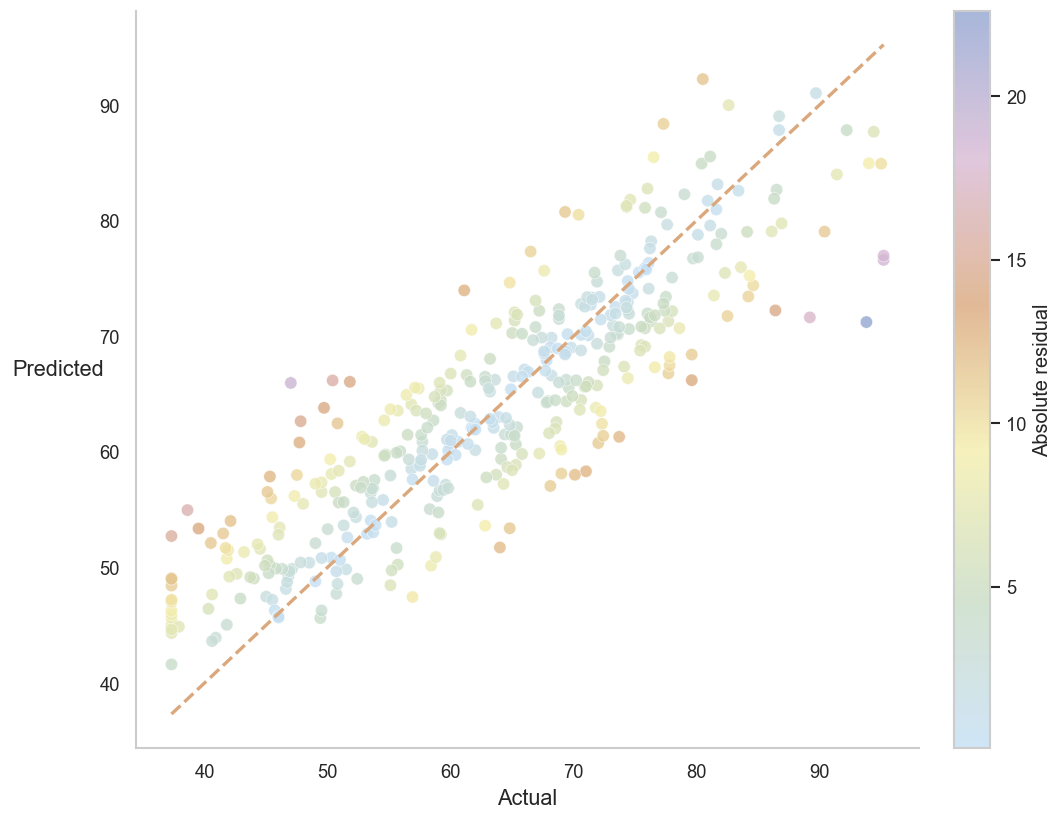

In [38]:
# ---------- Predicted vs Actual ----------
pred_full = model_full.predict(X_test)
residuals = y_test - pred_full
abs_residuals = np.abs(residuals)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(y_test, pred_full, c=abs_residuals, cmap=soft_cmap,
                s=55, alpha=0.8, edgecolor='white', linewidth=0.35)

# 45° 参考线
lims = [min(y_test.min(), pred_full.min()), max(y_test.max(), pred_full.max())]
ax.plot(lims, lims, '--', color=palette['orange'], linewidth=2)

set_axis_labels(ax, xlabel='Actual', ylabel='Predicted', y_rot=0, y_labelpad=25)
clean_axis(ax)

cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Absolute residual', fontsize=12)

plt.tight_layout()
plt.show()